## Imports


In [1]:
from pathlib import Path
import sys

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import wandb

In [2]:
PROJECT_ROOT = Path.cwd()

# If notebook is launched from the notebooks/ folder, go one level up.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# If src/ is still not found, try parent directory.
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path("..").resolve()

sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: /home/xizusha/Documents/ML/Facial-Expression-Recognition
src exists: True


## Configuration

In [3]:
from src.constants import EMOTION_LABELS, NUM_CLASSES, IMAGE_SIZE
from src.dataset import FER2013Dataset
from src.train_utils import (
    set_seed,
    get_device,
    count_parameters,
    train_one_epoch,
    evaluate,
)

In [4]:
CONFIG = {
    "dataset": "FER2013",
    "model_name": "mlp_hidden2_underfit",
    "architecture_type": "mlp",
    "input_shape": "1x48x48",
    "normalization": "training_mean_std",
    "augmentation": "none",
    "hidden_size": 2,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "batch_size": 64,
    "epochs": 10,
    "weight_decay": 0.0,
    "seed": 42,
    "train_split": "Training",
    "val_split": "PublicTest",
}

CSV_PATH = PROJECT_ROOT / "data/raw/fer2013/fer2013.csv"

WANDB_ENTITY = "lkhiz23-free-university-of-tbilisi-"
WANDB_PROJECT = "facial-expression-recognition"

ENABLE_WANDB = True

## Reproducibility and Device

In [5]:
set_seed(CONFIG["seed"])

device = get_device()

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


## Data Loading

In [6]:
train_dataset = FER2013Dataset(
    CSV_PATH,
    split=CONFIG["train_split"],
)

val_dataset = FER2013Dataset(
    CSV_PATH,
    split=CONFIG["val_split"],
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

images, labels = next(iter(train_loader))

print("Batch images:", images.shape)
print("Batch labels:", labels.shape)
print("Image min:", images.min().item())
print("Image max:", images.max().item())

Train samples: 28709
Validation samples: 3589
Batch images: torch.Size([64, 1, 48, 48])
Batch labels: torch.Size([64])
Image min: -1.9910776615142822
Image max: 1.9303536415100098


## Model Architecture

In [7]:
class MLPBaseline(nn.Module):
    def __init__(self, hidden_size=2, num_classes=NUM_CLASSES):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(IMAGE_SIZE * IMAGE_SIZE, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x):
        return self.net(x)


model = MLPBaseline(hidden_size=CONFIG["hidden_size"]).to(device)
model

MLPBaseline(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2304, out_features=2, bias=True)
    (2): ReLU()
    (3): Linear(in_features=2, out_features=7, bias=True)
  )
)

## Parameter Count

In [8]:
num_parameters = count_parameters(model)

print("Trainable parameters:", num_parameters)

CONFIG["num_parameters"] = num_parameters
CONFIG["device"] = device

Trainable parameters: 4631


## Forward/Backward Check

In [9]:
criterion = nn.CrossEntropyLoss()

sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

sample_outputs = model(sample_images)
sample_loss = criterion(sample_outputs, sample_labels)

model.zero_grad()
sample_loss.backward()

print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)
print("Loss:", sample_loss.item())
print("Backward pass: OK")

assert sample_outputs.shape == (sample_images.size(0), NUM_CLASSES)

Input shape: torch.Size([64, 1, 48, 48])
Output shape: torch.Size([64, 7])
Loss: 1.871769666671753
Backward pass: OK


## W&B Initialization

In [10]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)

run = None

if ENABLE_WANDB:
    run = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name="run_00_mlp_hidden2_underfit",
        config=CONFIG,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/xizusha/.netrc.
wandb: Currently logged in as: lkhiz23 (lkhiz23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Training

In [11]:
history = []

best_val_accuracy = 0.0
best_val_macro_f1 = 0.0

for epoch in range(1, CONFIG["epochs"] + 1):
    train_loss, train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_loss, val_metrics, val_labels, val_preds = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    best_val_accuracy = max(best_val_accuracy, val_metrics["accuracy"])
    best_val_macro_f1 = max(best_val_macro_f1, val_metrics["macro_f1"])

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "best_val_accuracy": best_val_accuracy,
        "best_val_macro_f1": best_val_macro_f1,
    }

    history.append(row)

    if ENABLE_WANDB:
        wandb.log(row)

    print(
        f"Epoch {epoch:02d}/{CONFIG['epochs']} | "
        f"train_loss={train_loss:.4f} "
        f"train_acc={train_metrics['accuracy']:.4f} "
        f"train_f1={train_metrics['macro_f1']:.4f} | "
        f"val_loss={val_loss:.4f} "
        f"val_acc={val_metrics['accuracy']:.4f} "
        f"val_f1={val_metrics['macro_f1']:.4f}"
    )

Epoch 01/10 | train_loss=1.7687 train_acc=0.3032 train_f1=0.1710 | val_loss=1.7110 val_acc=0.3346 val_f1=0.2037


Epoch 02/10 | train_loss=1.7121 train_acc=0.3285 train_f1=0.2010 | val_loss=1.6937 val_acc=0.3383 val_f1=0.2044


Epoch 03/10 | train_loss=1.6949 train_acc=0.3374 train_f1=0.2062 | val_loss=1.6906 val_acc=0.3349 val_f1=0.1991


Epoch 04/10 | train_loss=1.6843 train_acc=0.3401 train_f1=0.2102 | val_loss=1.6770 val_acc=0.3419 val_f1=0.2076


Epoch 05/10 | train_loss=1.6779 train_acc=0.3420 train_f1=0.2090 | val_loss=1.6750 val_acc=0.3410 val_f1=0.2025


Epoch 06/10 | train_loss=1.6717 train_acc=0.3471 train_f1=0.2109 | val_loss=1.6878 val_acc=0.3402 val_f1=0.2001


Epoch 07/10 | train_loss=1.6662 train_acc=0.3484 train_f1=0.2133 | val_loss=1.6653 val_acc=0.3461 val_f1=0.2085


Epoch 08/10 | train_loss=1.6656 train_acc=0.3479 train_f1=0.2149 | val_loss=1.6684 val_acc=0.3508 val_f1=0.2153


Epoch 09/10 | train_loss=1.6613 train_acc=0.3494 train_f1=0.2129 | val_loss=1.6626 val_acc=0.3505 val_f1=0.2136


Epoch 10/10 | train_loss=1.6581 train_acc=0.3527 train_f1=0.2125 | val_loss=1.6717 val_acc=0.3444 val_f1=0.2109


## Results

In [12]:
if ENABLE_WANDB:
    class_names = [EMOTION_LABELS[i] for i in range(NUM_CLASSES)]

    wandb.log({
        "validation_confusion_matrix": wandb.plot.confusion_matrix(
            y_true=val_labels,
            preds=val_preds,
            class_names=class_names,
        )
    })

    run.summary["best_val_accuracy"] = best_val_accuracy
    run.summary["best_val_macro_f1"] = best_val_macro_f1
    run.finish()

best_val_accuracy,▁▃▃▄▄▄▆███
best_val_macro_f1,▁▁▁▃▃▃▄███
epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▅▆▆▆▇▇▇██
train_loss,█▄▃▃▂▂▂▁▁▁
train_macro_f1,▁▆▇▇▇▇████
val_accuracy,▁▃▁▄▄▃▆██▅
val_loss,█▅▅▃▃▅▁▂▁▂
val_macro_f1,▃▃▁▅▂▁▅█▇▆
best_val_accuracy,0.35079
best_val_macro_f1,0.21526


In [13]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,best_val_accuracy,best_val_macro_f1
0,1,1.768748,1.710952,0.303250,0.334634,0.171034,0.203717,0.334634,0.203717
1,2,1.712053,1.693668,0.328468,0.338256,0.201009,0.204352,0.338256,0.204352
2,3,1.694925,1.690635,0.337385,0.334912,0.206240,0.199099,0.338256,0.204352
3,4,1.684297,1.676971,0.340068,0.341878,0.210151,0.207586,0.341878,0.207586
4,5,1.677924,1.674991,0.342018,0.341042,0.208968,0.202483,0.341878,0.207586
5,6,1.671745,1.687821,0.347139,0.340206,0.210912,0.200134,0.341878,0.207586
6,7,1.666233,1.665282,0.348427,0.346057,0.213315,0.208475,0.346057,0.208475
7,8,1.665578,1.668427,0.347870,0.350794,0.214874,0.215263,0.350794,0.215263
8,9,1.661310,1.662588,0.349368,0.350515,0.212868,0.213596,0.350794,0.215263
9,10,1.658093,1.671734,0.352747,0.344386,0.212456,0.210869,0.350794,0.215263


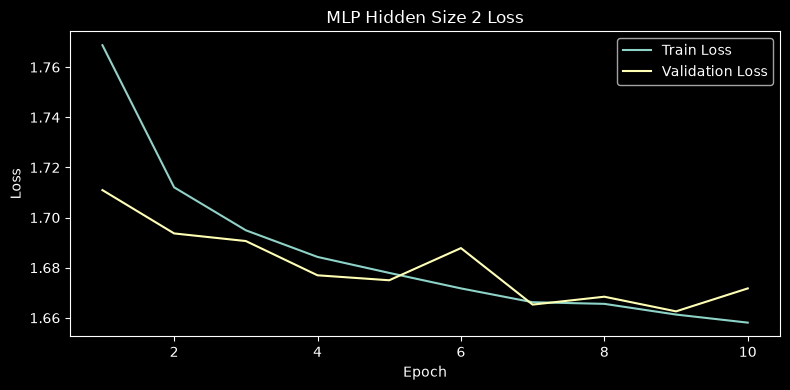

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Hidden Size 2 Loss")
plt.legend()
plt.tight_layout()

plt.savefig("../images/mlp_hidden2_loss.png", dpi=150, bbox_inches="tight")
plt.show()

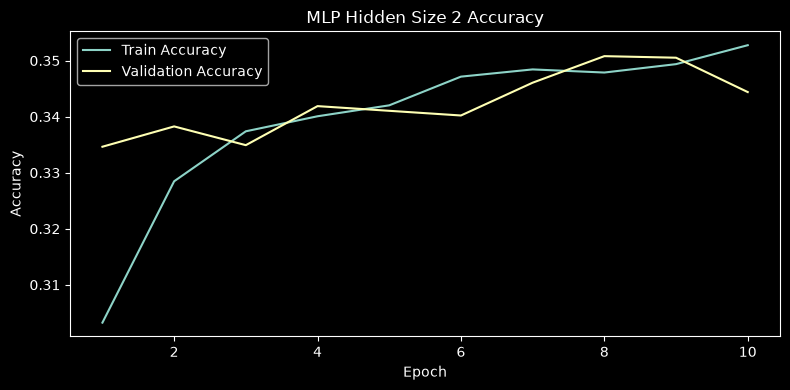

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Hidden Size 2 Accuracy")
plt.legend()
plt.tight_layout()

plt.savefig("../images/mlp_hidden2_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
summary = {
    "model": CONFIG["model_name"],
    "hidden_size": CONFIG["hidden_size"],
    "num_parameters": CONFIG["num_parameters"],
    "best_val_accuracy": best_val_accuracy,
    "best_val_macro_f1": best_val_macro_f1,
}

summary

{'model': 'mlp_hidden2_underfit',
 'hidden_size': 2,
 'num_parameters': 4631,
 'best_val_accuracy': 0.3507940930621343,
 'best_val_macro_f1': 0.2152629751050166}